In [1]:
import matplotlib.pyplot as plt
import tiktoken
import os
from collections import Counter
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*MKL.*')

## Data prep

In [2]:
from langchain_community.document_loaders import PyPDFLoader

docs = list()

for pdf in ["papers/corrective rag.pdf", "papers/modular rag.pdf", "papers/self rag.pdf"]:
    loader = PyPDFLoader(pdf)
    pages = loader.load_and_split()
    docs.extend(pages)

leaf_texts = [d.page_content for d in docs]

In [40]:
leaf_texts[0]

"Corrective Retrieval Augmented Generation\nShi-Qi Yan1*, Jia-Chen Gu2*, Yun Zhu3, Zhen-Hua Ling1\n1National Engineering Research Center of Speech and Language Information Processing,\nUniversity of Science and Technology of China, Hefei, China\n2Department of Computer Science, University of California, Los Angeles\n3Google Research\nyansiki@mail.ustc.edu.cn ,gujc@ucla.edu ,yunzhu@google.com ,zhling@ustc.edu.cn\nAbstract\nLarge language models (LLMs) inevitably\nexhibit hallucinations since the accuracy of\ngenerated texts cannot be secured solely by\nthe parametric knowledge they encapsulate. Al-\nthough retrieval-augmented generation (RAG)\nis a practicable complement to LLMs, it relies\nheavily on the relevance of retrieved docu-\nments, raising concerns about how the model\nbehaves if retrieval goes wrong. To this end, we\npropose the Corrective Retrieval Augmented\nGeneration ( CRAG ) to improve the robustness\nof generation. Specifically, a lightweight\nretrieval evaluator is des

In [39]:
len(leaf_texts)

103

<function matplotlib.pyplot.show(close=None, block=None)>

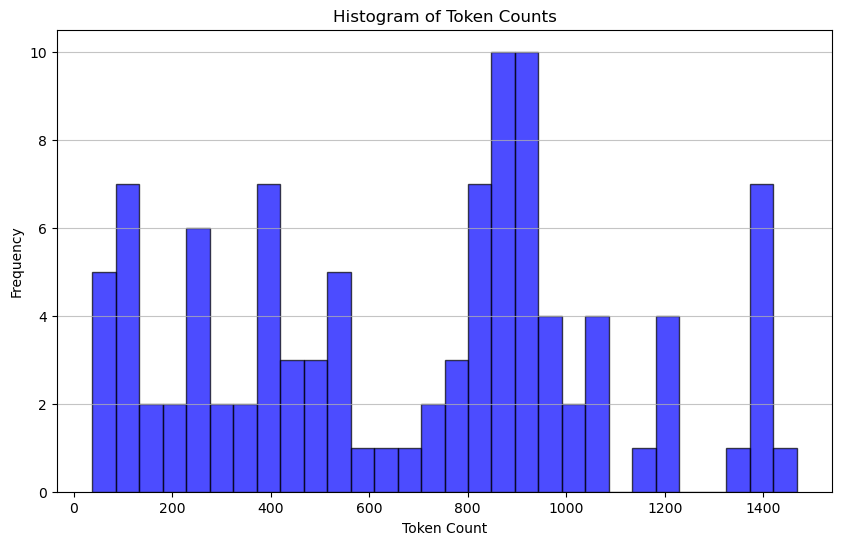

In [4]:
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# 각 페이지 토큰의 개수
counts = [num_tokens_from_string(d, "cl100k_base") for d in leaf_texts]

# Plotting the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Histogram of Token Counts")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# Display the histogram
plt.show


In [5]:
# Doc texts concat
d_sorted = sorted(docs, key=lambda x: x.metadata["source"])
d_reversed = list(reversed(d_sorted))
concatenated_content = "\n\n\n --- \n\n\n".join(
    [doc.page_content for doc in d_reversed]
)
print(
    "Num tokens in all context: %s"
    % num_tokens_from_string(concatenated_content, "cl100k_base")
)

Num tokens in all context: 71239


In [ ]:
leaf_texts

## Model config

## Construct tree

<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. <mark> 데이터 준비 </mark>

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- Global cluster 생성
- Global cluster 내에서 local cluster 생성
- 각 cluster 별로 summary node 생성

- 생성된 summary node를 기준으로 다음 레벨의 summary node 생성
- Tree를 flatten하여 vectorDB에 저장

### 2. Langchain pipeline
- Langchain pipeline 생성
</div>

In [41]:
from raptor_rag import *

In [10]:
len(leaf_texts)

103

In [42]:
## embedding으로 변환
embeddings = embed(leaf_texts)

In [12]:
len(embeddings)

103

In [44]:
embeddings[0].shape

(1536,)

#### --- create cluster ---

<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. 데이터 준비

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- <mark>Global cluster 생성</mark>
- Global cluster 내에서 local cluster 생성
- 각 cluster 별로 summary node 생성

- 생성된 summary node를 기준으로 다음 레벨의 summary node 생성
- Tree를 flatten하여 vectorDB에 저장

### 2. Langchain pipeline
- Langchain pipeline 생성


</div>


In [13]:
dim = 10
threshold = 0.1

umap

In [14]:
reduced_embeddings_global = global_cluster_embeddings(embeddings, dim)
reduced_embeddings_global.shape

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(103, 10)

In [45]:
reduced_embeddings_global[0]

array([ 6.140743  ,  5.728769  ,  6.0422573 ,  4.934403  ,  2.6068246 ,
        2.3680863 , -0.8493772 ,  0.54428357,  3.8614187 ,  3.9925768 ],
      dtype=float32)

In [46]:
n_clusters = get_optimal_clusters(reduced_embeddings_global)
print(n_clusters)

4


```python
def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """
    Determine the optimal number of clusters using the Bayesian Information Criterion (BIC) with a Gaussian Mixture Model.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - max_clusters: The maximum number of clusters to consider.
    - random_state: Seed for reproducibility.

    Returns:
    - An integer representing the optimal number of clusters found.
    """
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]


def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    """
    Cluster embeddings using a Gaussian Mixture Model (GMM) based on a probability threshold.

    Parameters:
    - embeddings: The input embeddings as a numpy array.
    - threshold: The probability threshold for assigning an embedding to a cluster.
    - random_state: Seed for reproducibility.

    Returns:
    - A tuple containing the cluster labels and the number of clusters determined.
    """
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters

```

- 최적의 클러스터 갯수 탐색
- threshold를 기준으로 각 data point 별로 속하는 클러스터에 대한 레이블 부여

In [47]:
# Global clustering
global_clusters, n_global_clusters = GMM_cluster(
    reduced_embeddings_global, threshold
)

all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
total_clusters = 0

In [48]:
n_global_clusters

4

In [49]:
# 클러스터와 갯수
Counter([i[0] for i in global_clusters])

Counter({2: 36, 1: 26, 0: 23, 3: 18})

<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. 데이터 준비

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- Global cluster 생성
- <mark> Global cluster 내에서 local cluster 생성 </mark>
- 각 cluster 별로 summary node 생성

- 생성된 summary node를 기준으로 다음 레벨의 summary node 생성
- Tree를 flatten하여 vectorDB에 저장

### 2. Langchain pipeline
- Langchain pipeline 생성
</div>

In [51]:
# 각 글로벌 클러스터 내에서 로컬 클러스터 생성
for i in range(n_global_clusters):
    # Extract embeddings belonging to the current global cluster
    global_cluster_embeddings_ = embeddings[
        np.array([i in gc for gc in global_clusters])
    ]
    
    # cluster가 없거나 작을 것에 대비
    if len(global_cluster_embeddings_) == 0:
        continue
    if len(global_cluster_embeddings_) <= dim + 1:
        # Handle small clusters with direct assignment
        local_clusters = [np.array([0]) for _ in global_cluster_embeddings_]
        n_local_clusters = 1
    else:
        # Local dimensionality reduction and clustering
        reduced_embeddings_local = local_cluster_embeddings(
            global_cluster_embeddings_, dim
        )
        local_clusters, n_local_clusters = GMM_cluster(
            reduced_embeddings_local, threshold
        )
    # 로컬 클러스터 생성
    # Assign local cluster IDs, adjusting for total clusters already processed
    for j in range(n_local_clusters):
        local_cluster_embeddings_ = global_cluster_embeddings_[
            np.array([j in lc for lc in local_clusters])
        ]
        indices = np.where(
            (embeddings == local_cluster_embeddings_[:, None]).all(-1)
        )[1]
        for idx in indices:
            all_local_clusters[idx] = np.append(
                all_local_clusters[idx], j + total_clusters
            )

    total_clusters += n_local_clusters

    print("Global 클러스터 {}에 {}개의 local 클러스터 생성".format(str(i), str(n_local_clusters)))

Global 클러스터 0에 4개의 local 클러스터 생성
Global 클러스터 1에 5개의 local 클러스터 생성
Global 클러스터 2에 7개의 local 클러스터 생성
Global 클러스터 3에 5개의 local 클러스터 생성


In [53]:
total_clusters

21

cluster들을 dataframe으로 변환

In [20]:
df_clusters = pd.DataFrame()  # Initialize a DataFrame to store the results
df_clusters["text"] = leaf_texts  # Store original texts
df_clusters["embd"] = list(embeddings)  # Store embeddings as a list in the DataFrame
df_clusters["cluster"] = all_local_clusters  # Store cluster labels

In [62]:
df_clusters.head()

,text,embd,cluster
0,Corrective Retrieval Augmented Generation\nShi...,"[0.013704836368560791, 0.02550254948437214, 0....",[19.0]
1,impeding the models from acquiring accurate\nk...,"[-0.002226433018222451, 0.03961097076535225, 0...",[17.0]
2,"2021), either outdated information or incorrec...","[-0.0018162305932492018, 0.011791134253144264,...",[19.0]
3,sparse or dense retrievers at the front end of...,"[0.007228814531117678, 0.04339922219514847, 0....",[19.0]
4,knowledge sources for corrections (Section 4.5...,"[-0.00417040940374136, 0.03206992149353027, 0....",[19.0]


<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. 데이터 준비

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- Global cluster 생성
- Global cluster 내에서 local cluster 생성
- <mark> 각 cluster 별로 summary node 생성 </mark>
- 생성된 summary node를 기준으로 다음 레벨의 summary node 생성
- Tree를 flatten하여 vectorDB에 저장

### 2. Langchain pipeline
- Langchain pipeline 생성
</div>

In [22]:
# 한 row에 하나의 클러스터만 오도록
expanded_list = []

# Expand DataFrame entries to document-cluster pairings for straightforward processing
for index, row in df_clusters.iterrows():
    for cluster in row["cluster"]:
        expanded_list.append(
            {"text": row["text"], "embd": row["embd"], "cluster": cluster}
        )

# Create a new DataFrame from the expanded list
expanded_df = pd.DataFrame(expanded_list)

# Retrieve unique cluster identifiers for processing
all_clusters = expanded_df["cluster"].unique()

print(f"--Generated {len(all_clusters)} clusters--")

--Generated 21 clusters--


In [23]:
expanded_df.head()

,text,embd,cluster
0,Corrective Retrieval Augmented Generation\nShi...,"[0.013704836368560791, 0.02550254948437214, 0....",19.0
1,impeding the models from acquiring accurate\nk...,"[-0.002226433018222451, 0.03961097076535225, 0...",17.0
2,"2021), either outdated information or incorrec...","[-0.0018162305932492018, 0.011791134253144264,...",19.0
3,sparse or dense retrievers at the front end of...,"[0.007228814531117678, 0.04339922219514847, 0....",19.0
4,knowledge sources for corrections (Section 4.5...,"[-0.00417040940374136, 0.03206992149353027, 0....",19.0


각 클러스터 별로 요약을 진행함

In [24]:
# Summarization
template = """Give a detailed summary of the documentation provided.

Documentation:
{context}
"""
prompt = ChatPromptTemplate.from_template(template)
chain = prompt | model | StrOutputParser()

In [25]:
all_clusters

array([19., 17., 20., 18.,  7.,  6.,  5.,  9., 16.,  1.,  3.,  2.,  0.,
       10.,  4., 11.,  8., 12., 15., 13., 14.])

In [26]:
# Format text within each cluster for summarization
summaries = []
for i in tqdm(all_clusters):
    df_cluster = expanded_df[expanded_df["cluster"] == i]
    formatted_txt = fmt_txt(df_cluster)
    summaries.append(chain.invoke({"context": formatted_txt}))

  0%|          | 0/21 [00:00<?, ?it/s]

In [27]:
level=1

In [28]:
# Create a DataFrame to store summaries with their corresponding cluster and level
df_summary = pd.DataFrame(
    {
        "summaries": summaries,
        "level": [level] * len(summaries),
        "cluster": list(all_clusters),
    }
)

In [63]:
df_summary

,summaries,level,cluster
0,### Summary of the Documentation on Corrective...,1,19.0
1,The provided documentation discusses a novel a...,1,17.0
2,The provided documentation presents a comprehe...,1,20.0
3,The provided documentation details the evaluat...,1,18.0
4,The provided documentation primarily discusses...,1,7.0
5,The provided documentation is a comprehensive ...,1,6.0
6,The provided documentation is a comprehensive ...,1,5.0
7,The provided documentation outlines the method...,1,9.0
8,The provided documentation details the experim...,1,16.0
9,The provided documentation is a comprehensive ...,1,1.0


<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. 데이터 준비

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- Global cluster 생성
- Global cluster 내에서 local cluster 생성
- 각 cluster 별로 summary node 생성 
- <mark> 생성된 summary node를 기준으로 다음 레벨의 summary node 생성</mark>
- Tree를 flatten하여 vectorDB에 저장

### 2. Langchain pipeline
- Langchain pipeline 생성
</div>

In [29]:
n_levels = 3 # 총 레벨3까지 노드를 생성.

In [30]:
results = {}  # Dictionary to store results at each level
results[level] = (df_clusters, df_summary)

In [31]:
# 글로벌 클러스터 생성 -> 각 클러스터 내에서 로컬 클러스터 생성
# -> 각 클러스터 별로 summary node 생성

# Determine if further recursion is possible and meaningful
unique_clusters = df_summary["cluster"].nunique()
if level < n_levels and unique_clusters > 1:
    # Use summaries as the input texts for the next level of recursion
    new_texts = df_summary["summaries"].tolist()
    next_level_results = recursive_embed_cluster_summarize(
        new_texts, level + 1, n_levels
    )

    # Merge the results from the next level into the current results dictionary
    results.update(next_level_results)

Global 클러스터 0에 1개의 local 클러스터 생성
Global 클러스터 1에 1개의 local 클러스터 생성
Global 클러스터 2에 1개의 local 클러스터 생성
Global 클러스터 3에 1개의 local 클러스터 생성
--Generated 4 clusters--
--Generated 1 clusters--


In [ ]:
- leaf node 103
- 21
- 4
- 1

```python

leaf_texts = docs_texts
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)

```

<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. 데이터 준비

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- Global cluster 생성
- Global cluster 내에서 local cluster 생성
- 각 cluster 별로 summary node 생성

- 생성된 summary node를 기준으로 다음 레벨의 summary node 생성
- <mark> Tree를 flatten하여 vectorDB에 저장</mark>

### 2. Langchain pipeline
- Langchain pipeline 생성

</div>

In [32]:
from langchain_community.vectorstores import Chroma

# Initialize all_texts with leaf_texts
all_texts = leaf_texts.copy()

# Iterate through the results to extract summaries from each level and add them to all_texts
for level in sorted(results.keys()):
    # Extract summaries from the current level's DataFrame
    summaries = results[level][1]["summaries"].tolist()
    # Extend all_texts with the summaries from the current level
    all_texts.extend(summaries)

# Now, use all_texts to build the vectorstore with Chroma
vectorstore = Chroma.from_texts(texts=all_texts, embedding=embd)
retriever = vectorstore.as_retriever()

<div style="background-color: #e0f7fa; padding: 10px; border: 1px solid #ddd; border-radius: 5px;">

### 0. 데이터 준비

- 데이터 로딩
- 임베딩

### 1. Tree 구축

- Global cluster 생성
- Global cluster 내에서 local cluster 생성
- 각 cluster 별로 summary node 생성

- 생성된 summary node를 기준으로 다음 레벨의 summary node 생성
- Tree를 flatten하여 vectorDB에 저장

### 2. <mark> Langchain pipeline </mark>
- Langchain pipeline 생성

</div>

In [33]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

In [34]:
question = "What are three limitations of Naive RAG?"

In [35]:
system = """You are an assistant for question-answering tasks. 
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise."""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "\nQuestion: {question} \nContext: {context} \nAnswer:",
        ),
    ]
)

In [64]:
# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

# Question
output = rag_chain.invoke(question)

In [37]:
print(output)

Three limitations of Naive RAG are:

1. **Retrieval Challenges**: The retrieval phase often struggles with precision and recall, leading to the selection of misaligned or irrelevant chunks and missing crucial information.
2. **Generation Difficulties**: The model may produce hallucinated content not supported by the retrieved context, and the outputs can suffer from irrelevance, toxicity, or bias.
3. **Augmentation Hurdles**: Integrating retrieved information can be challenging, sometimes resulting in disjointed or incoherent outputs, redundancy, and difficulty in determining the significance and relevance of various passages.


In [66]:
# Question
output = rag_chain.invoke("What is the difference between self rag and corrective rag?")

-- END --